# Variaciones del mismo digito


### En este notebook se observan distintas reconstrucciones del mismo dígito


#### Datos

Se usaron los datos de MNIST para entrenar los modelos y visualizar las variaciones por dígito (genericamente clase).


#### Modelo


Se usaron los modelos de diminesiones 128_2 y 256_128 (intermedia y latente respectivamente) para visualizar.


In [3]:
import os
import sys

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../..")))

from project.loader import load

dataset="mnist"
inter=256
lat=64

cvae_0 = load.cvae(inter=inter,lat=lat,dataset=dataset)


models = load.all_models(dataset=dataset)

predictor = load.predictor(dataset)
data =  load.data(dataset)

x_train = data["x_train"]
x_train_1 = data["x_train_1"]
y_train = data["y_train"]
y_train_1 = data["y_train_1"]
x_test = data["x_test"]
y_test  =data["y_test"]

#models = load.all_models(dataset=dataset)

2026-01-29 20:06:37.753110: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-29 20:06:37.753535: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-29 20:06:37.756089: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-29 20:06:37.762884: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769727997.773975  201195 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769727997.77

Encontrados 7 pares de modelos.
Usando mnist como dataset


In [8]:
for modelo in models:
    print(modelo)

<CVAE name=cvae_int_128_lat_2, built=False>
<CVAE name=cvae_int_128_lat_64, built=False>
<CVAE name=cvae_int_256_lat_128, built=False>
<CVAE name=cvae_int_256_lat_64, built=False>
<CVAE name=cvae_int_512_lat_128, built=False>
<CVAE name=cvae_int_512_lat_256, built=False>
<CVAE name=cvae_int_784_lat_784, built=False>


## Visualizaciones:

Variaciones por dígito de cvae_0


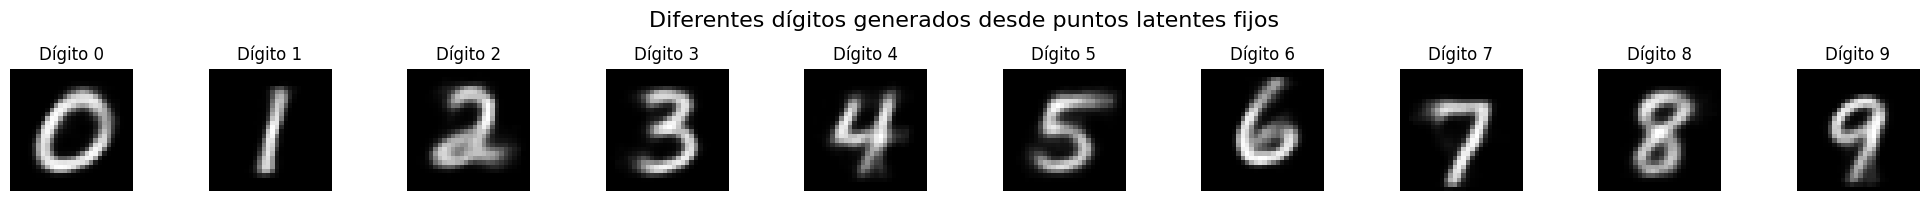

[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


In [2]:
import project.visualizations.visualizations as vis
import numpy as np
num_puntos = 1

puntos=vis.variantes_punto_fijo(cvae=cvae_0,z_fixed=np.zeros(shape=(num_puntos,lat)),num_puntos=1) #se toma un punto del espacio latente para las reconstrucciones
print(puntos)

Para ambos modelos parece haber una buena reconstrucción de dígitos. Bastante peor en el caso del modelo cvae_0. los modelos fueron entrenados hasta que earystop los freno.




<CVAE name=cvae_int_128_lat_2, built=False>
<CVAE name=cvae_int_128_lat_64, built=False>
<CVAE name=cvae_int_256_lat_128, built=False>
<CVAE name=cvae_int_256_lat_64, built=False>
<CVAE name=cvae_int_512_lat_128, built=False>
<CVAE name=cvae_int_512_lat_256, built=False>
<CVAE name=cvae_int_784_lat_784, built=False>

cvae_int_128_lat_2


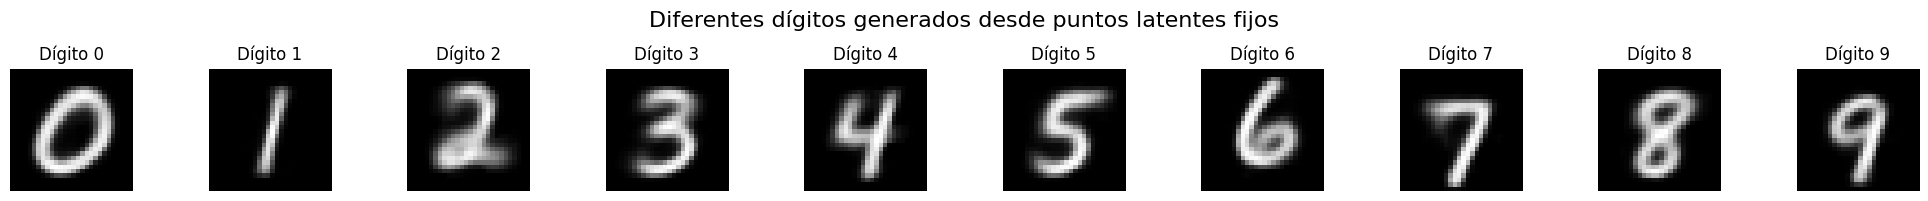

cvae_int_128_lat_64


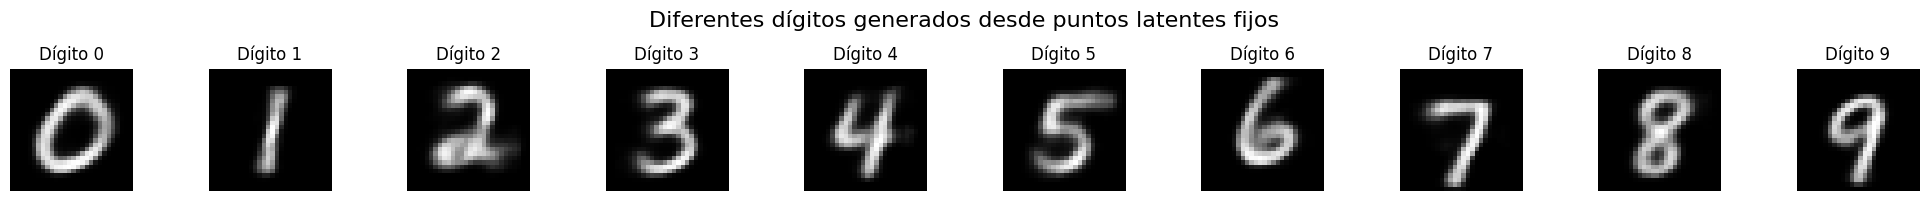

cvae_int_256_lat_128


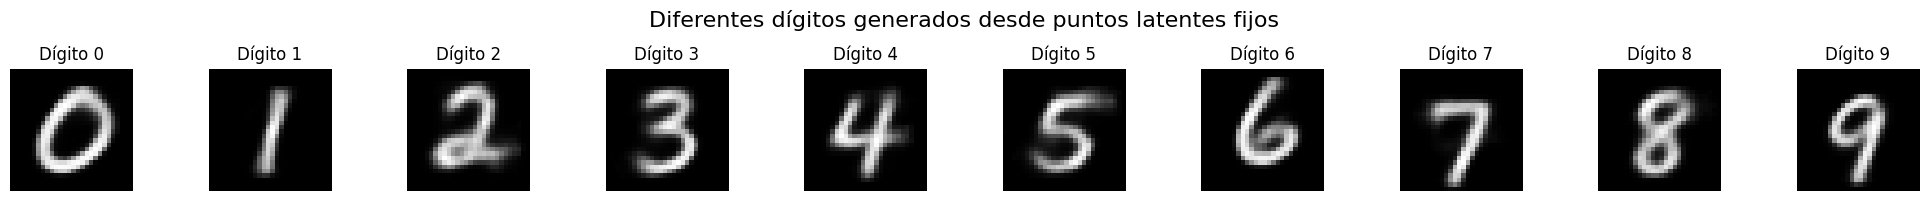

cvae_int_256_lat_64


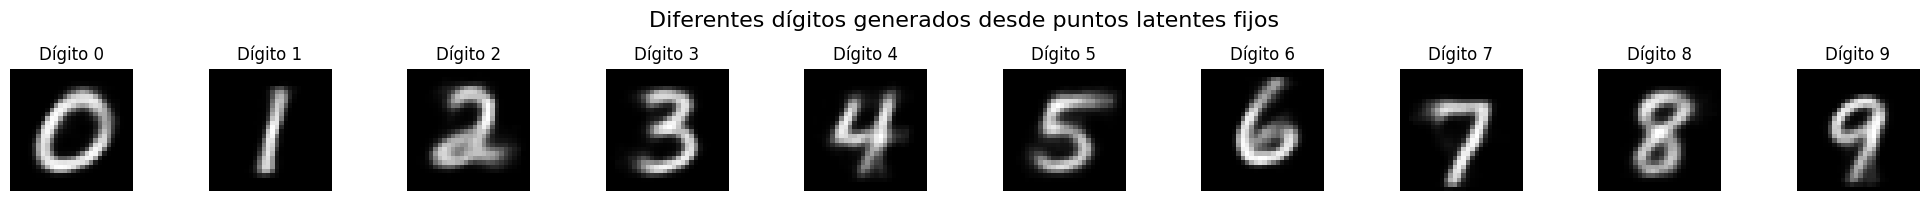

cvae_int_512_lat_128


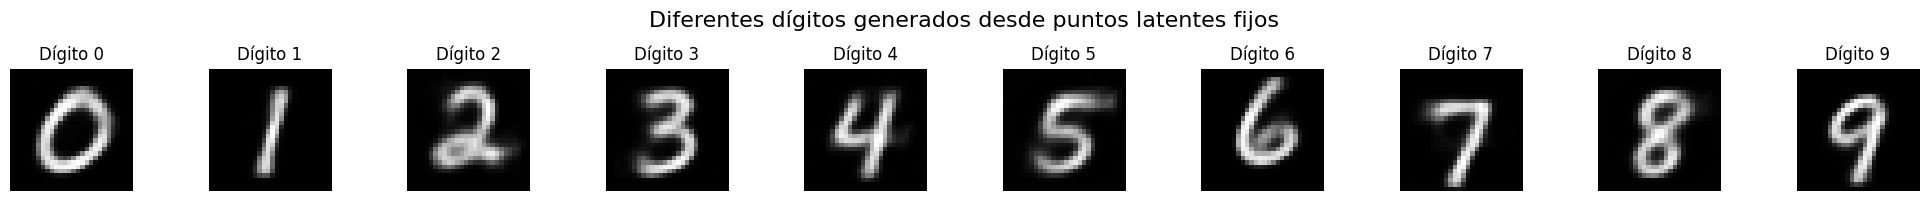

cvae_int_512_lat_256


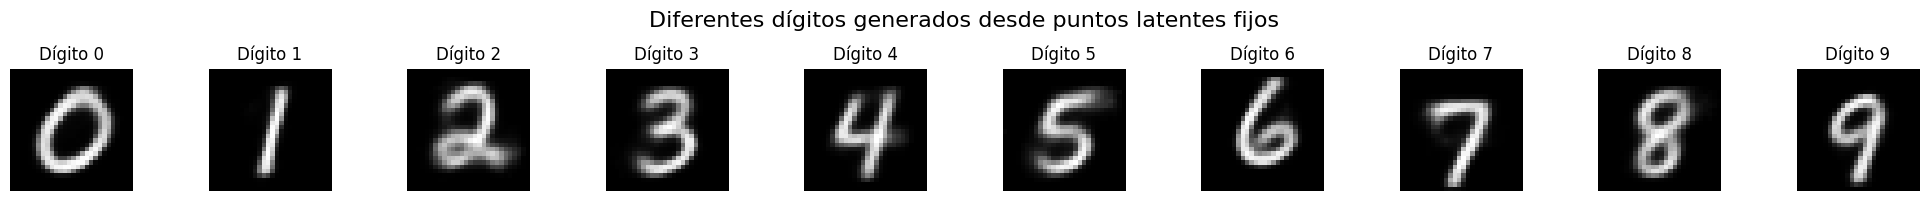

cvae_int_784_lat_784


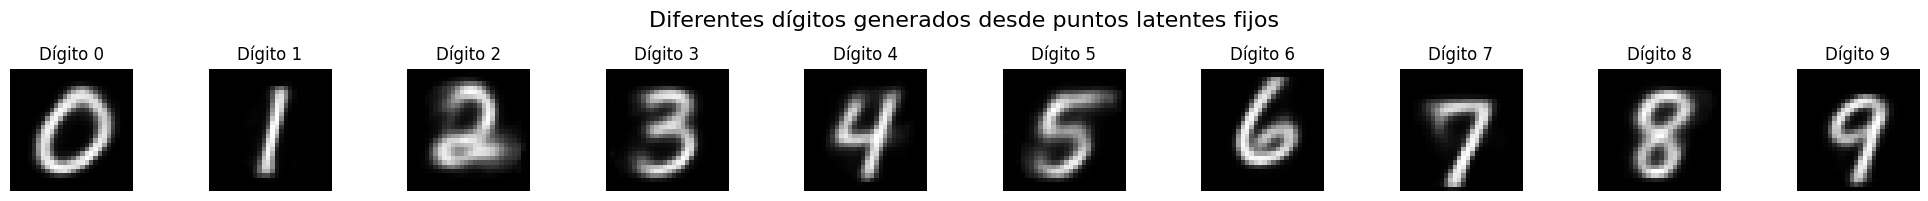

In [10]:
lat = [2,64,128,64,128,256,784] 
for i in range(len(lat)):
    print(models[i].name)
    vis.variantes_punto_fijo(cvae=models[i],z_fixed=np.zeros(shape=(num_puntos,lat[i])),num_puntos=1)

## Condiciones anómalas

condición en el decoder y enconder en 0 o aleatoreo


[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


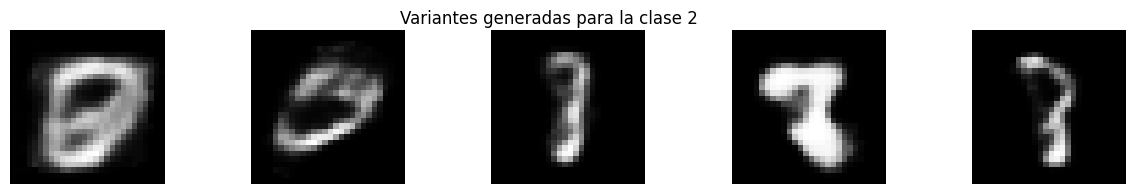

array([[ 1.36480198e+00, -1.10841234e+00, -9.34162982e-01,
        -4.48372172e-01, -8.35318621e-01,  3.61424897e-01,
        -3.50527200e-01, -3.52714557e-01, -6.93285059e-02,
         6.62767646e-02, -1.45823056e+00, -2.06316067e-01,
         9.00890470e-01,  6.76121002e-02, -3.41585796e-01,
        -9.35682521e-01, -2.66577678e-01, -1.78967676e-01,
         5.85296338e-02, -7.97455004e-02, -1.94196627e+00,
         1.80091433e+00, -1.01654315e+00,  5.51131433e-01,
        -1.07392323e-01, -1.23057008e+00,  6.34138452e-01,
        -6.08879058e-01,  1.20284573e+00,  1.05110754e+00,
        -6.66616693e-01,  5.49142121e-01, -3.67655032e-01,
        -2.99685730e-01, -7.40812937e-01,  6.03743937e-01,
        -9.62941686e-01, -4.37178116e-01, -1.23685323e+00,
        -8.36429048e-01, -1.18468854e-02,  1.39274386e+00,
        -1.86237049e-01,  4.33006911e-02, -3.75306918e-01,
         8.45963646e-03, -4.13717677e-01, -1.46080057e+00,
        -1.33495607e+00,  1.86705610e-03,  4.96917872e-0

In [11]:
import project.visualizations.visualizations as vis
import importlib
import numpy as np

importlib.reload(vis)
num_variantes = 5
custom_condition = np.zeros(shape=(num_variantes, 10))
#custom_condition = np.random.uniform(0,1,size=(num_variantes,10))
"""
1) probar poner 0s al encoder.

2) entrenar un encoder sin clases en la entrada (quizas ponerle 0 en la entrada, sino cambiar 
                                                la arquitectura para que no tenga condicion. Verficar si es lo mismo)


"""
print(custom_condition)
vis.variantes(
    cvae=cvae_0,
    condicion_id=2,
    num_variantes=num_variantes,
    custom_condition=custom_condition,
)

## Variaciones sobre una componente del espaico latente 

In [3]:
def recorrer_latente_2d(
    cvae,
    x_input,
    condicion_id,
    idx1=0,
    idx2=1,
    sides=8,
    max_z=1.5
):
    import numpy as np
    import matplotlib.pyplot as plt

    x_input = np.expand_dims(x_input, axis=0)
    condicion = np.eye(10)[condicion_id].reshape(1, -1)

    z_mean, _, _ = cvae.encoder.predict([x_input, condicion], verbose=0)

    grid = np.linspace(-max_z, max_z, sides)
    fig = plt.figure(figsize=(sides, sides))

    img_it = 0
    for i, z1 in enumerate(grid):
        for j, z2 in enumerate(grid):
            z = z_mean.copy()
            z[0, idx1] = z1
            z[0, idx2] = z2

            decoded = cvae.decoder.predict(
                [z, condicion],
                verbose=0
            )

            plt.subplot(sides, sides, img_it + 1)
            plt.imshow(decoded[0].reshape(28, 28), cmap="gray")
            plt.axis("off")
            img_it += 1

    plt.suptitle(
        f"Recorrido latente z[{idx1}] vs z[{idx2}] — clase {condicion_id}",
        fontsize=14
    )
    plt.subplots_adjust(wspace=0, hspace=0)
    plt.show()


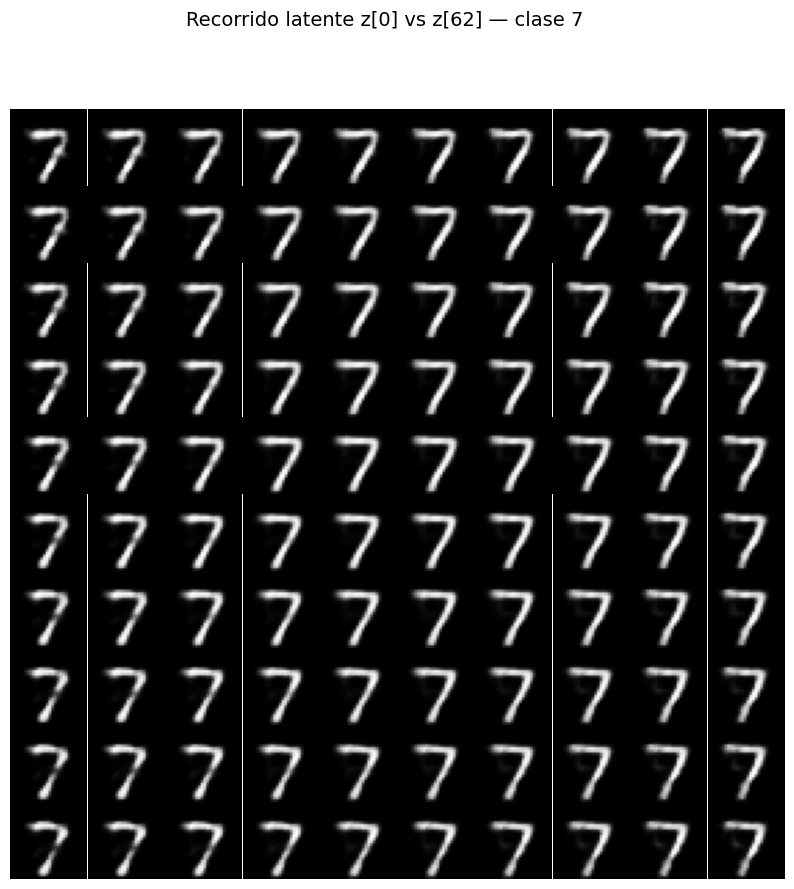

In [13]:

import numpy as np
recorrer_latente_2d(
    cvae_0,
    x_input=x_test[0],     # shape (28, 28)
    condicion_id=np.argmax(y_test[0]),
    idx1=0,
    idx2=62,
    sides=10,
    max_z=30
)